Assignemnmt Name: Data Science Assignment: Employee Attrition Classification

Data Set: Employee.xlsx

Target Variable: LeaveOrNot (0 = stayed, 1 = left)

Objective:
Predict whether an employee will leave the company using classification techniques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **Part 1**

In [4]:
ds= pd.read_excel('Employee.xlsx')

In [7]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [8]:
ds.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [9]:
ds.isna().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [11]:
ds.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [14]:
ds.Education.value_counts()

Education
Bachelors    3601
Masters       873
PHD           179
Name: count, dtype: int64

In [15]:
ds.City.value_counts()

City
Bangalore    2228
Pune         1268
New Delhi    1157
Name: count, dtype: int64

In [16]:
ds.Gender.value_counts()

Gender
Male      2778
Female    1875
Name: count, dtype: int64

In [17]:
ds.EverBenched.value_counts()

EverBenched
No     4175
Yes     478
Name: count, dtype: int64

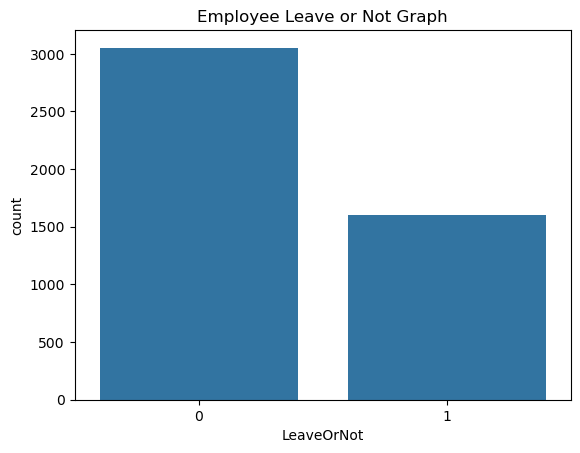

In [20]:
sns.countplot(x=ds.LeaveOrNot)
plt.title('Employee Leave or Not Graph')
plt.show()

## **Part 2**

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for a in ['Education','City','Gender','EverBenched']:
        ds[a] = le.fit_transform(ds[a])

In [22]:
ds.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,0,2017,0,3,34,1,0,0,0
1,0,2013,2,1,28,0,0,3,1
2,0,2014,1,3,38,0,0,2,0
3,1,2016,0,3,27,1,0,5,1
4,1,2017,2,3,24,1,1,2,1


In [26]:
from sklearn.preprocessing import StandardScaler
sl = StandardScaler()
scl_col =[
    'Age',
    'ExperienceInCurrentDomain',
    'JoiningYear',
    'PaymentTier'
]
ds[scl_col] =  sl.fit_transform(ds[scl_col])

In [27]:
ds.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,0,1.039638,0,0.537503,0.954645,1,0,-1.864901,0
1,0,-1.107233,2,-3.025177,-0.288732,0,0,0.060554,1
2,0,-0.570515,1,0.537503,1.783563,0,0,-0.581264,0
3,1,0.502921,0,0.537503,-0.495961,1,0,1.344191,1
4,1,1.039638,2,0.537503,-1.117650,1,1,-0.581264,1


In [28]:
x = ds.drop('LeaveOrNot',axis=1)
y = ds.LeaveOrNot

In [31]:
from sklearn import preprocessing
pre_process = preprocessing.StandardScaler().fit(x)
x_transform = pre_process.fit_transform(x)

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_transform, y, test_size= .20 ,random_state=101)

In [36]:
y_train

3150    0
929     0
657     0
3124    0
72      0
       ..
4079    0
4171    0
599     0
1361    1
1547    1
Name: LeaveOrNot, Length: 3722, dtype: int64

## **Part 3&4**

Decision Tree Classifier Model

In [39]:
from sklearn.tree import DecisionTreeClassifier
Dtree = DecisionTreeClassifier()
Dtree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
from sklearn.metrics import accuracy_score
#Predict
y_pred_Dtree =Dtree.predict(x_test)
#Accurace
print('--'*30)
Dtree_accouracy = round(accuracy_score(y_test,y_pred_Dtree)*100,2)
print('Accuracy',Dtree_accouracy,'%')

------------------------------------------------------------
Accuracy 81.74 %


Random Forest Classifier Model

In [40]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
from sklearn.metrics import accuracy_score
#Prdict
y_pred_rfc =rfc.predict(x_test)
#Accurace
print('--'*30)
rfc_accouracy = round(accuracy_score(y_test,y_pred_rfc)*100,2)
print('Accuracy',rfc_accouracy,'%')

------------------------------------------------------------
Accuracy 82.92 %


## **Part 5**

Task 1

In [52]:
important = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rfc.feature_importances_
})
important = important.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                     Feature  Importance
1                JoiningYear    0.333872
4                        Age    0.166706
2                       City    0.113028
3                PaymentTier    0.101991
5                     Gender    0.092081
0                  Education    0.091795
7  ExperienceInCurrentDomain    0.080633
6                EverBenched    0.019894


plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('Feature Important in Random Forest')
plt.show()

The most important features identified by the model were Joining Year, Age, and city. These features had the greatest influence on predicting employee attrition.

Task 2

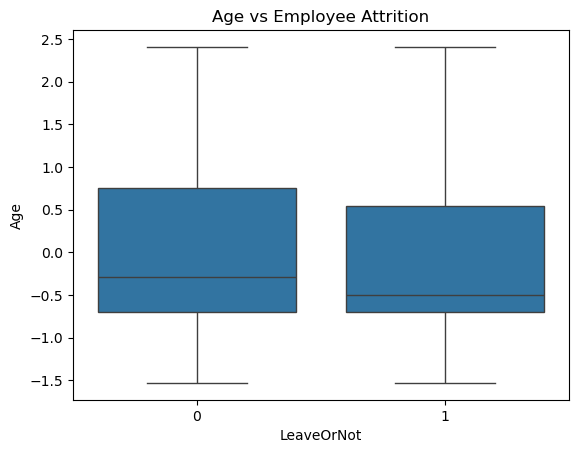

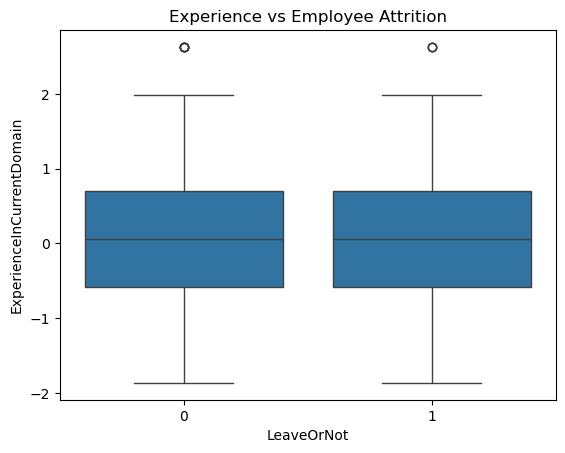

In [57]:
sns.boxplot(x=ds.LeaveOrNot, y='Age', data=ds)
plt.title('Age vs Employee Attrition')
plt.show()

sns.boxplot(x='LeaveOrNot', y='ExperienceInCurrentDomain', data=ds)
plt.title('Experience vs Employee Attrition')
plt.show()

The boxplots show that Age and ExperienceInCurrentDomain have a similar distribution for employees who stayed and those who left. Therefore, these factors do not appear to have a strong impact on employee attrition.

Task 3

Decision Tree Accuracy: 81.74%
Random Forest Accuracy: 82.92%
Rendom Forest is Better because it give more accurate result then decision tree

Task 4

Provide career growth and training opportunities for employees.
Review compensation and benefits to improve employee satisfaction.
Implement mentoring and support programs to increase employee retention.

In [46]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rfc.feature_importances_
})

NameError: name 'features' is not defined